In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

LOAD THE DATASET

In [2]:
df = pd.read_csv("C:/Users/MARS/Desktop/retail_sales_dataset.csv")
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (1000, 9)

First 5 rows:
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


DATA CLEANING

In [9]:
print("\nCleaning")

# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Validate calculation: Total Amount should equal Quantity * Price per Unit
df["Calculated_Total"] = df["Quantity"] * df["Price per Unit"]
mismatches = (df["Total Amount"] != df["Calculated_Total"]).sum()
print(f"Mismatched Total Amount rows: {mismatches}")

# Drop the temporary validation column
df = df.drop(columns=["Calculated_Total"])


Cleaning
Missing values:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
Duplicate rows: 0
Mismatched Total Amount rows: 0


EXPLORATORY DATA ANALYSIS

In [10]:
print("\n Summary")
print(df.describe())

# 1. Total Revenue and Volume by Product Category
category_summary = (
    df.groupby("Product Category")
    .agg(
        Total_Revenue=("Total Amount", "sum"),
        Average_Sale=("Total Amount", "mean"),
        Transaction_Count=("Transaction ID", "count"),
    )
    .reset_index()
)
print("\nCategory Summary:")
print(category_summary)

# 2. Sales Performance by Gender
gender_summary = (
    df.groupby("Gender")
    .agg(
        Total_Revenue=("Total Amount", "sum"),
        Average_Spent=("Total Amount", "mean"),
    )
    .reset_index()
)
print("\nGender Summary:")
print(gender_summary)


 Summary
       Transaction ID                        Date         Age     Quantity  \
count     1000.000000                        1000  1000.00000  1000.000000   
mean       500.500000  2023-07-03 00:25:55.200000    41.39200     2.514000   
min          1.000000         2023-01-01 00:00:00    18.00000     1.000000   
25%        250.750000         2023-04-08 00:00:00    29.00000     1.000000   
50%        500.500000         2023-06-29 12:00:00    42.00000     3.000000   
75%        750.250000         2023-10-04 00:00:00    53.00000     4.000000   
max       1000.000000         2024-01-01 00:00:00    64.00000     4.000000   
std        288.819436                         NaN    13.68143     1.132734   

       Price per Unit  Total Amount  
count     1000.000000   1000.000000  
mean       179.890000    456.000000  
min         25.000000     25.000000  
25%         30.000000     60.000000  
50%         50.000000    135.000000  
75%        300.000000    900.000000  
max        500.000000

In [ ]:
#1. Total Sales by Product Category
plt.figure()
sns.barplot(
    data=category_summary,
    x="Product Category",
    y="Total_Revenue",
    palette="viridis",
)
plt.title("Total Revenue by Product Category", fontsize=14, fontweight="bold")
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)
plt.savefig("revenue_by_category.png", bbox_inches="tight")
plt.show()

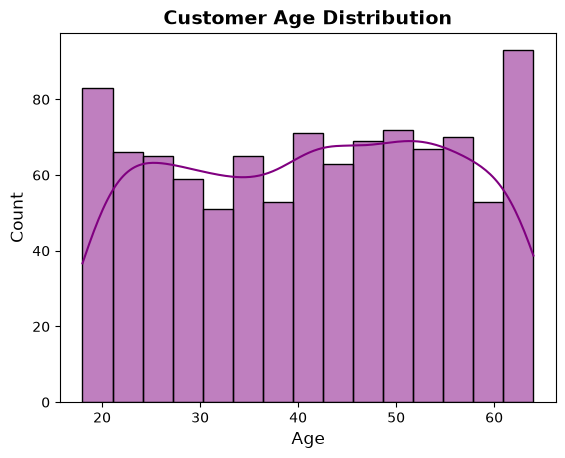

In [ ]:
# 2. Customer Age Distribution
plt.figure()
sns.histplot(
    df["Age"], bins=15, kde=True, color="purple"
)
plt.title("Customer Age Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Age", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.savefig("age_distribution.png", bbox_inches="tight")
plt.show()